SARIMA Model

ARIMA Model

Train length: 1438
Test length : 289


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     Tagesumsatz Restaurant   No. Observations:                 1438
Model:                     ARIMA(5, 1, 3)   Log Likelihood              -13928.028
Date:                    Sun, 30 Nov 2025   AIC                          27874.055
Time:                            08:39:49   BIC                          27921.488
Sample:                                 0   HQIC                         27891.764
                                   - 1438                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0929      0.048      1.918      0.055      -0.002       0.188
ar.L2         -0.8223      0.045    -18.463      0.000      -0.910      -0.735
ar.L3         -0.007

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


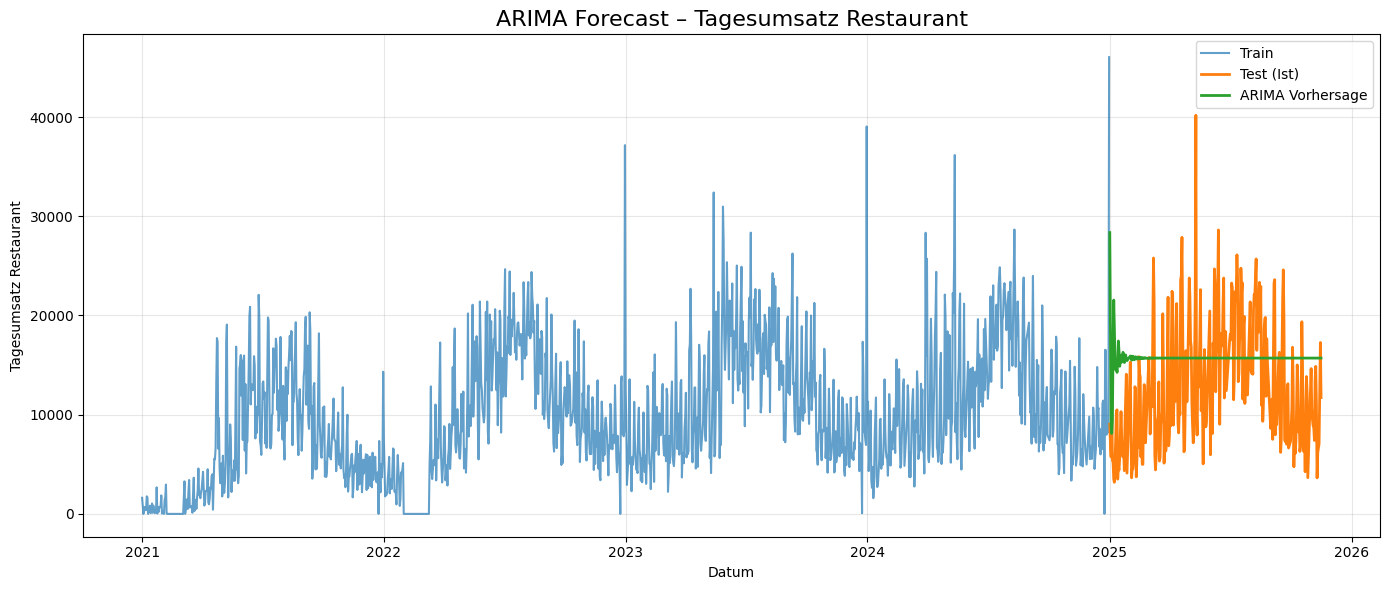

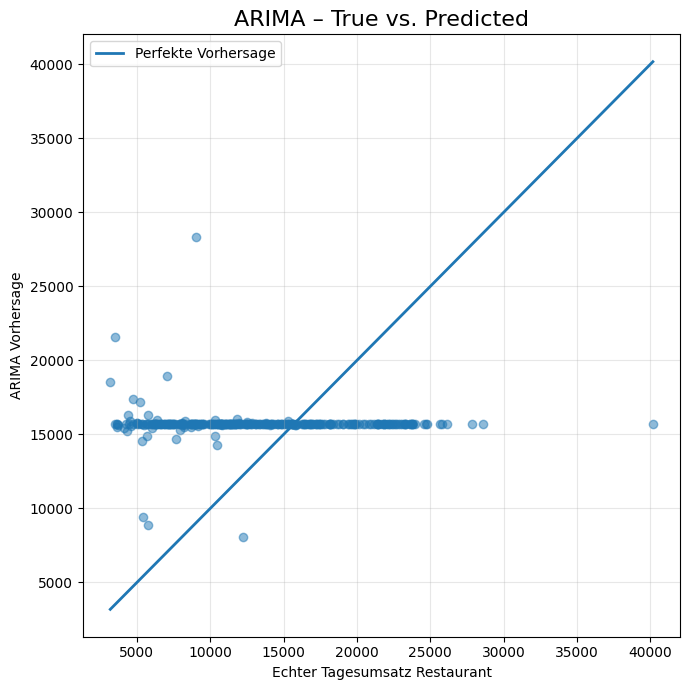

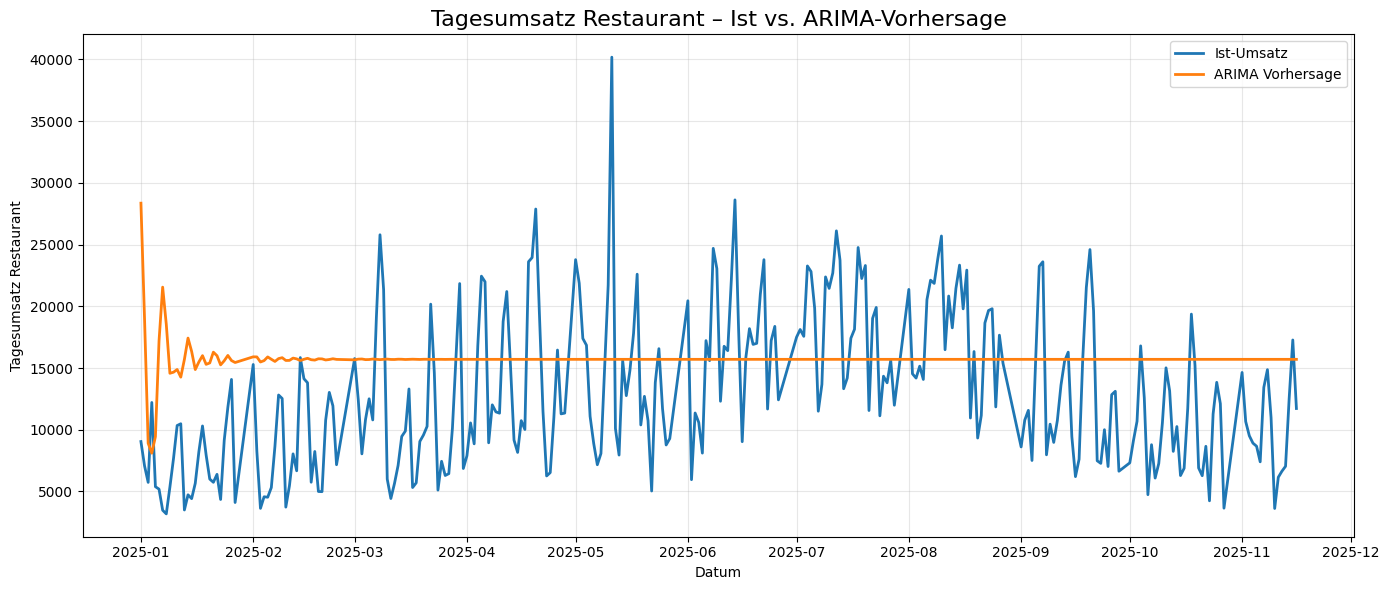

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

# 1) Dataset laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Univariate Zeitreihe für ARIMA (Target = Tagesumsatz Restaurant)
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# 3) Train / Test Split (zeitbasiert)
split_date = pd.Timestamp("2025-01-01")

train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# 4) ARIMA-Modell fitten
order = (5, 1, 3)   # kann man später noch tunen

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

# 5) Forecast über Testperiode
forecast = model_fit.forecast(steps=len(test))

# 6) Evaluation
mse  = mean_squared_error(test, forecast)
rmse = mse ** 0.5
r2   = r2_score(test, forecast)

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

# 7) Plot: Train, Test (Ist) und Forecast
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (Ist)", linewidth=2)
plt.plot(test.index, forecast, label="ARIMA Vorhersage", linewidth=2)

plt.title("ARIMA Forecast – Tagesumsatz Restaurant", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8) Scatter Plot: True vs Forecast
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast.values, alpha=0.5)
plt.plot([min(test), max(test)], [min(test), max(test)],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("ARIMA – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz Restaurant")
plt.ylabel("ARIMA Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Zeitreihen-Plot: Ist vs. Vorhersage (nur Testperiode, schön kompakt)

results_arima = pd.DataFrame({
    "Datum": test.index,
    "Ist": test.values,
    "Vorhersage": forecast.values
})

plt.figure(figsize=(14,6))
plt.plot(results_arima["Datum"], results_arima["Ist"], 
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_arima["Datum"], results_arima["Vorhersage"], 
         label="ARIMA Vorhersage", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. ARIMA-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()